CT Data - Train: 96000, Val: 12000, Test: 12000
MRI Data - Train: 86400, Val: 10800, Test: 10800
Using device: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([768]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([768, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([768]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([768, 768]) in the model instantiated
You should probably TRAIN this model on a

Pretrained CT and MRI backbone weights loaded.
Starting training...
Epoch 1/25
  Train Loss: 0.7063, Train Acc: 0.7374
  Val Loss: 0.3655, Val Acc: 0.7366
  LR: 0.000100
  New best model saved! Val Acc: 0.7366
Epoch 2/25
  Train Loss: 0.6977, Train Acc: 0.7355
  Val Loss: 0.3656, Val Acc: 0.7364
  LR: 0.000100
Epoch 3/25
  Train Loss: 0.6974, Train Acc: 0.7365
  Val Loss: 0.3649, Val Acc: 0.7366
  LR: 0.000100
Unfreezing more layers...
Epoch 4/25
  Train Loss: 0.6958, Train Acc: 0.7369
  Val Loss: 0.3651, Val Acc: 0.7366
  LR: 0.000050
Epoch 5/25
  Train Loss: 0.6956, Train Acc: 0.7352
  Val Loss: 0.3650, Val Acc: 0.7367
  LR: 0.000050
  New best model saved! Val Acc: 0.7367
Epoch 6/25
  Train Loss: 0.6957, Train Acc: 0.7360
  Val Loss: 0.3647, Val Acc: 0.7366
  LR: 0.000025
Epoch 7/25
  Train Loss: 0.6952, Train Acc: 0.7371
  Val Loss: 0.3646, Val Acc: 0.7366
  LR: 0.000025
Epoch 8/25
  Train Loss: 0.6948, Train Acc: 0.7364
  Val Loss: 0.3664, Val Acc: 0.7366
  LR: 0.000025
Epoch 9/25

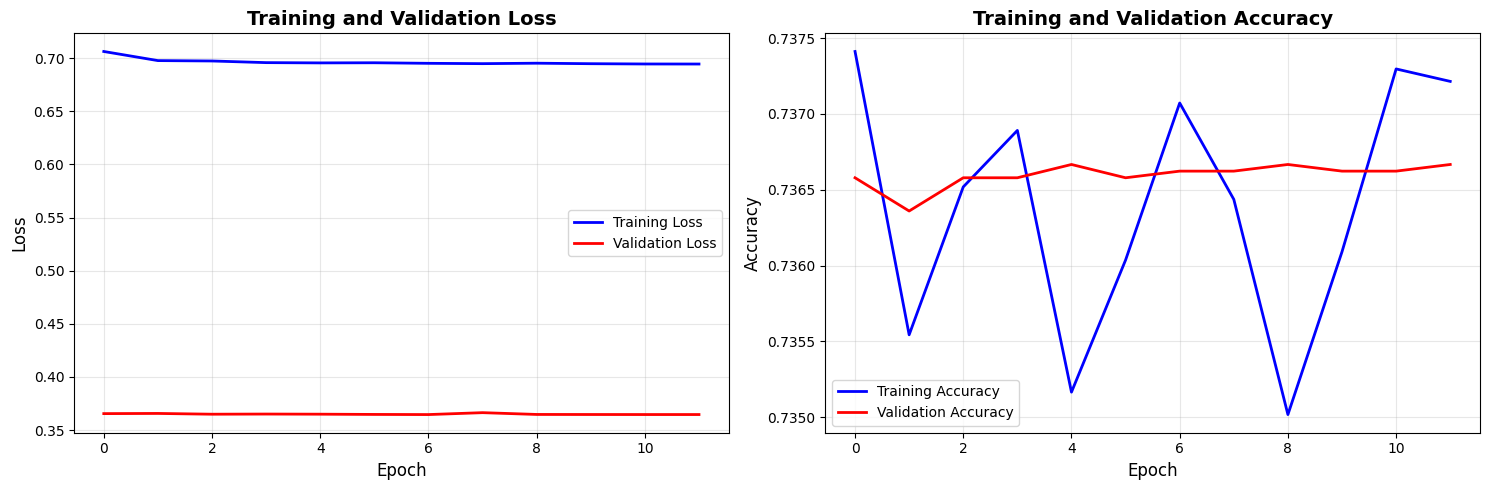

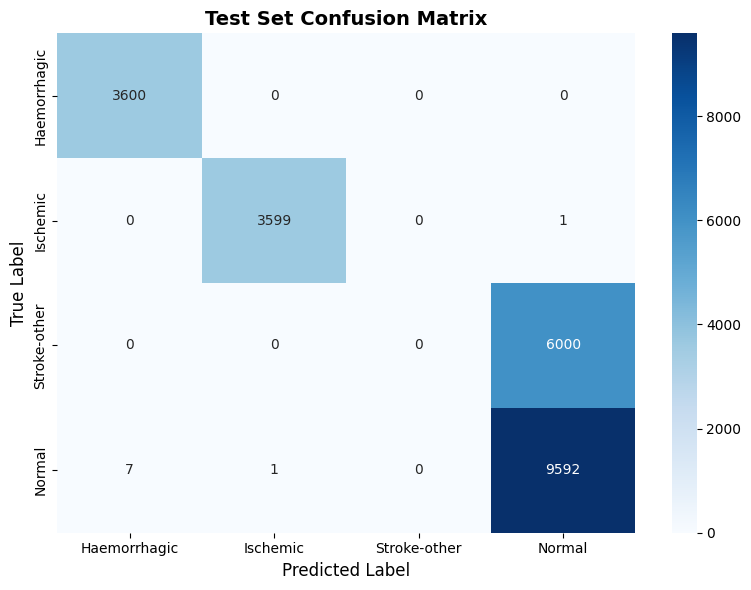

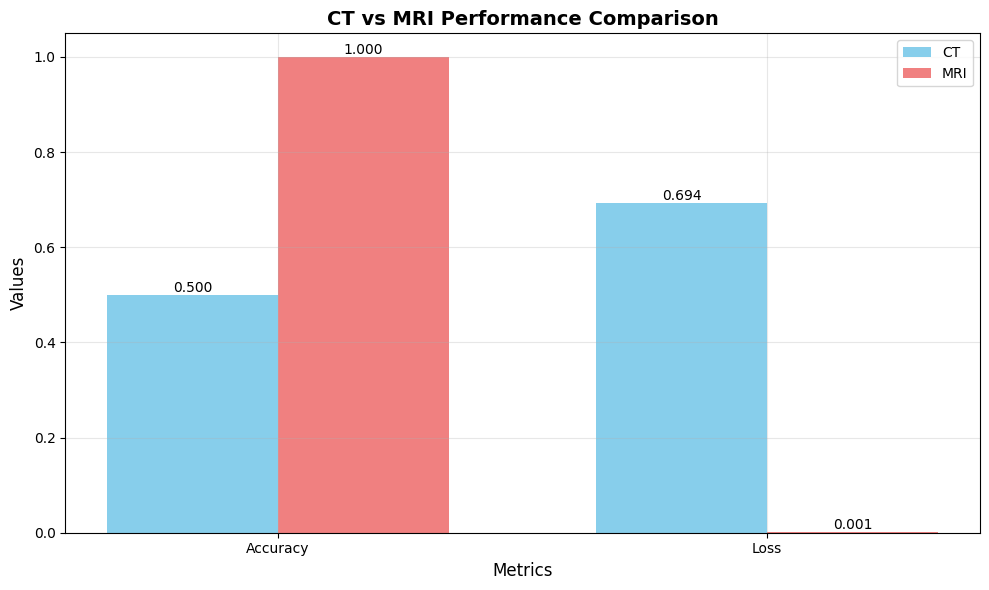


Training complete! Final model saved.
Best validation accuracy: 0.7367
Test accuracy: 0.7364


In [ ]:
# Standard library imports
import os
from collections import defaultdict

# Third-party imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels

# Transformers
from transformers import ViTForImageClassification

# ------------------------
# 1. Dataset Definitions
# ------------------------
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

class UnpairedFusionDataset(Dataset):
    """
    Combines CT and MRI samples for alternating batches.
    Each sample: (image, label, modality)
    """
    def __init__(self, ct_paths, ct_labels, mri_paths, mri_labels, transform):
        self.samples = []
        for p, l in zip(ct_paths, ct_labels):
            self.samples.append(('CT', p, l))
        for p, l in zip(mri_paths, mri_labels):
            self.samples.append(('MRI', p, l))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        modality, path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label, modality

# ------------------------
# 2. Fusion Model Definition
# ------------------------
class DualViTFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_classes=4):
        super().__init__()
        # Pretrained ViT backbones outputting hidden_dim features
        self.vit_ct = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224', num_labels=hidden_dim, ignore_mismatched_sizes=True)
        self.vit_mri = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224', num_labels=hidden_dim, ignore_mismatched_sizes=True)
        # Cross-attention fusion
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads=8)
        # Classification head on fused feature
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, ct=None, mri=None):
        # Determine batch size
        bs = ct.shape[0] if ct is not None else mri.shape[0]
        # Extract CLS token features from each modality
        if ct is not None:
            out_ct = self.vit_ct.vit(ct).last_hidden_state  # (bs, seq_len, hidden)
            feat_ct = out_ct[:, 0]
        else:
            feat_ct = torch.zeros(bs, self.vit_ct.config.hidden_size, device=next(self.parameters()).device)

        if mri is not None:
            out_mri = self.vit_mri.vit(mri).last_hidden_state
            feat_mri = out_mri[:, 0]
        else:
            feat_mri = torch.zeros(bs, self.vit_mri.config.hidden_size, device=next(self.parameters()).device)

        # Cross-attention fusion
        query = feat_ct.unsqueeze(0)
        key = feat_mri.unsqueeze(0)
        value = feat_mri.unsqueeze(0)
        fused, _ = self.cross_attn(query, key, value)
        fused = fused.squeeze(0)
        # Classification
        return self.classifier(fused)

# ------------------------
# 3. Weight Loading Utility
# ------------------------
def load_pretrained_weights(fusion_model, ct_weights_path, mri_weights_path):
    # Load CT weights
    ct_state = torch.load(ct_weights_path, map_location='cpu')
    # Filter and adjust keys for vit_ct backbone
    ct_dict = {k.replace('vit.', ''): v for k, v in ct_state.items() if k.startswith('vit.')}  # adjust prefix
    fusion_model.vit_ct.vit.load_state_dict(ct_dict, strict=False)

    # Load MRI weights
    mri_state = torch.load(mri_weights_path, map_location='cpu')
    mri_dict = {k.replace('vit.', ''): v for k, v in mri_state.items() if k.startswith('vit.')}  # adjust prefix
    fusion_model.vit_mri.vit.load_state_dict(mri_dict, strict=False)

    print("Pretrained CT and MRI backbone weights loaded.")

# ------------------------
# 4. Evaluation Functions
# ------------------------
def evaluate_model(model, loader, criterion, device, modality_type='mixed'):
    """
    Evaluate model on given data loader
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if modality_type == 'mixed':
                imgs, labels, modalities = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                # Process CT samples
                ct_mask = [m == 'CT' for m in modalities]
                if any(ct_mask):
                    ct_imgs = imgs[ct_mask]
                    ct_lbls = labels[ct_mask]
                    logits_ct = model(ct=ct_imgs, mri=None)
                    loss_ct = criterion(logits_ct, ct_lbls)
                    total_loss += loss_ct.item()
                    preds_ct = torch.argmax(logits_ct, dim=1)
                    all_preds.extend(preds_ct.cpu().numpy())
                    all_labels.extend(ct_lbls.cpu().numpy())

                # Process MRI samples
                mri_mask = [m == 'MRI' for m in modalities]
                if any(mri_mask):
                    mri_imgs = imgs[mri_mask]
                    mri_lbls = labels[mri_mask]
                    logits_mri = model(ct=None, mri=mri_imgs)
                    loss_mri = criterion(logits_mri, mri_lbls)
                    total_loss += loss_mri.item()
                    preds_mri = torch.argmax(logits_mri, dim=1)
                    all_preds.extend(preds_mri.cpu().numpy())
                    all_labels.extend(mri_lbls.cpu().numpy())
            else:
                # Single modality evaluation
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                if modality_type == 'CT':
                    logits = model(ct=imgs, mri=None)
                elif modality_type == 'MRI':
                    logits = model(ct=None, mri=imgs)

                loss = criterion(logits, labels)
                total_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy, all_preds, all_labels

# ------------------------
# 5. Plotting Functions
# ------------------------
def plot_training_curves(train_losses, val_losses, train_accs, val_accs, save_path='training_curves.png'):
    """
    Plot training and validation loss/accuracy curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(train_accs, label='Training Accuracy', color='blue', linewidth=2)
    ax2.plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix', save_path='confusion_matrix.png'):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_modality_comparison(ct_results, mri_results, class_names, save_path='modality_comparison.png'):
    """
    Compare CT and MRI performance
    """
    metrics = ['Accuracy', 'Loss']
    ct_values = [ct_results['accuracy'], ct_results['loss']]
    mri_values = [mri_results['accuracy'], mri_results['loss']]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, ct_values, width, label='CT', color='skyblue')
    bars2 = ax.bar(x + width/2, mri_values, width, label='MRI', color='lightcoral')

    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Values', fontsize=12)
    ax.set_title('CT vs MRI Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ------------------------
# 6. Main: Data, Training, and Fine-Tuning
# ------------------------
if __name__ == '__main__':
    # --- Config ---
    CT_DIR = '/content/Balanced_dataset'    # subfolders: ['Stroke','Normal']
    MRI_DIR = '/content/Balanced_MRI_Dataset'  # subfolders: ['Haemorrhagic','Ischemic','Normal']
    CT_WEIGHTS = '/content/Balanced_dataset_vit_stroke.pth'
    MRI_WEIGHTS = '/content/Aug_dataset_vit_stroke_mri.pth'
    BATCH_SIZE = 128
    NUM_EPOCHS = 25
    LR = 1e-4
    NUM_CLASSES = 4  # ['Haemorrhagic', 'Ischemic', 'Stroke-other', 'Normal']
    CLASS_NAMES = ['Haemorrhagic', 'Ischemic', 'Stroke-other', 'Normal']

    # --- Transforms ---
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485]*3, [0.229]*3)
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485]*3, [0.229]*3)
    ])

    # --- Load and Remap Labels ---
    def load_paths(root, classes):
        paths, labels = [], []
        for idx, cls in enumerate(classes):
            p_dir = os.path.join(root, cls)
            if not os.path.isdir(p_dir):
                print(f"Warning: Directory {p_dir} not found or inaccessible.")
                continue
            try:
                for fname in os.listdir(p_dir):
                    if fname.lower().endswith(('png','jpg','jpeg','bmp','tiff')):
                        paths.append(os.path.join(p_dir, fname))
                        labels.append(idx)
            except OSError as e:
                print(f"Warning: Cannot access directory {p_dir}: {e}")
                continue
        return paths, labels

    ct_paths, ct_labels = load_paths(CT_DIR, ['Stroke', 'Normal'])
    mri_paths, mri_labels = load_paths(MRI_DIR, ['Haemorrhagic', 'Ischemic', 'Normal'])

    # --- Remap CT and MRI labels to match fusion model CLASS_NAMES ---
    ct_label_remap = {0: 2, 1: 3}  # CT: Stroke → 2 ('Stroke-other'), Normal → 3 ('Normal')
    ct_labels = [ct_label_remap[lbl] for lbl in ct_labels]

    mri_label_remap = {0: 0, 1: 1, 2: 3}  # MRI: Haemorrhagic → 0, Ischemic → 1, Normal → 3
    mri_labels = [mri_label_remap[lbl] for lbl in mri_labels]

    # --- Split ---
    ct_train, ct_temp, lbl_ct_train, lbl_ct_temp = train_test_split(
        ct_paths, ct_labels, test_size=0.2, stratify=ct_labels, random_state=42)
    ct_val, ct_test, lbl_ct_val, lbl_ct_test = train_test_split(
        ct_temp, lbl_ct_temp, test_size=0.5, stratify=lbl_ct_temp, random_state=42)

    mri_train, mri_temp, lbl_mri_train, lbl_mri_temp = train_test_split(
        mri_paths, mri_labels, test_size=0.2, stratify=mri_labels, random_state=42)
    mri_val, mri_test, lbl_mri_val, lbl_mri_test = train_test_split(
        mri_temp, lbl_mri_temp, test_size=0.5, stratify=lbl_mri_temp, random_state=42)

    print(f"CT Data - Train: {len(ct_train)}, Val: {len(ct_val)}, Test: {len(ct_test)}")
    print(f"MRI Data - Train: {len(mri_train)}, Val: {len(mri_val)}, Test: {len(mri_test)}")

    # --- Datasets & Loaders ---
    train_ds = UnpairedFusionDataset(ct_train, lbl_ct_train, mri_train, lbl_mri_train, train_transform)
    val_ds = UnpairedFusionDataset(ct_val, lbl_ct_val, mri_val, lbl_mri_val, val_test_transform)
    test_ds = UnpairedFusionDataset(ct_test, lbl_ct_test, mri_test, lbl_mri_test, val_test_transform)

    val_ct_ds = ImageDataset(ct_val, lbl_ct_val, val_test_transform)
    val_mri_ds = ImageDataset(mri_val, lbl_mri_val, val_test_transform)
    test_ct_ds = ImageDataset(ct_test, lbl_ct_test, val_test_transform)
    test_mri_ds = ImageDataset(mri_test, lbl_mri_test, val_test_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

    val_ct_loader = DataLoader(val_ct_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    val_mri_loader = DataLoader(val_mri_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    test_ct_loader = DataLoader(test_ct_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    test_mri_loader = DataLoader(test_mri_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

    # Model setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model = DualViTFusion(hidden_dim=768, num_classes=NUM_CLASSES).to(device)
    if os.path.exists(CT_WEIGHTS) and os.path.exists(MRI_WEIGHTS):
        load_pretrained_weights(model, CT_WEIGHTS, MRI_WEIGHTS)
    else:
        print("Warning: Pretrained weights not found. Training from scratch.")

    # Freeze backbones
    for name, param in model.named_parameters():
        if 'classifier' not in name and 'cross_attn' not in name:
            param.requires_grad = False

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Tracking metrics
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0
    patience = 7
    patience_counter = 0

    print("Starting training...")
    for epoch in range(1, NUM_EPOCHS + 1):
        # Training
        model.train()
        total_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for imgs, labels, modalities in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            loss = 0.0

            # CT samples
            ct_mask = [m == 'CT' for m in modalities]
            if any(ct_mask):
                ct_imgs = imgs[ct_mask]
                ct_lbls = labels[ct_mask]
                logits_ct = model(ct=ct_imgs, mri=None)
                loss_ct = criterion(logits_ct, ct_lbls)
                loss += loss_ct
                preds_ct = torch.argmax(logits_ct, dim=1)
                all_train_preds.extend(preds_ct.cpu().numpy())
                all_train_labels.extend(ct_lbls.cpu().numpy())

            # MRI samples
            mri_mask = [m == 'MRI' for m in modalities]
            if any(mri_mask):
                mri_imgs = imgs[mri_mask]
                mri_lbls = labels[mri_mask]
                logits_mri = model(ct=None, mri=mri_imgs)
                loss_mri = criterion(logits_mri, mri_lbls)
                loss += loss_mri
                preds_mri = torch.argmax(logits_mri, dim=1)
                all_train_preds.extend(preds_mri.cpu().numpy())
                all_train_labels.extend(mri_lbls.cpu().numpy())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Calculate training metrics
        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_train_labels, all_train_preds)

        # Validation
        val_loss, val_acc, val_preds, val_labels = evaluate_model(
            model, val_loader, criterion, device, 'mixed')

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Learning rate scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")

        # Early stopping and model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_fusion_model.pth')
            print(f"  New best model saved! Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # Unfreeze more layers after initial epochs
        if epoch == 3:
            print("Unfreezing more layers...")
            for name, param in model.named_parameters():
                if 'classifier' in name or 'cross_attn' in name:
                    param.requires_grad = True
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/2, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    # --- Final Evaluation ---
    print("\n" + "="*50)
    print("FINAL EVALUATION")
    print("="*50)

    # Load best model
    model.load_state_dict(torch.load('best_fusion_model.pth'))

    # Test set evaluation
    test_loss, test_acc, test_preds, test_labels = evaluate_model(
        model, test_loader, criterion, device, 'mixed')

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Classification Report:")
    # Dynamically get present class indices
    present_labels = sorted(list(unique_labels(test_labels, test_preds)))
    present_class_names = [CLASS_NAMES[i] for i in present_labels]

    print(classification_report(test_labels, test_preds, target_names=present_class_names, labels=present_labels))

    # Individual modality evaluation
    ct_val_loss, ct_val_acc, ct_val_preds, ct_val_labels = evaluate_model(
        model, val_ct_loader, criterion, device, 'CT')

    mri_val_loss, mri_val_acc, mri_val_preds, mri_val_labels = evaluate_model(
        model, val_mri_loader, criterion, device, 'MRI')

    print(f"\nCT Validation - Loss: {ct_val_loss:.4f}, Acc: {ct_val_acc:.4f}")
    print(f"MRI Validation - Loss: {mri_val_loss:.4f}, Acc: {mri_val_acc:.4f}")

    # --- Visualization ---
    print("\nGenerating plots...")

    # Plot training curves
    plot_training_curves(train_losses, val_losses, train_accs, val_accs)

    # Plot confusion matrix
    plot_confusion_matrix(test_labels, test_preds, CLASS_NAMES, 'Test Set Confusion Matrix')

    # Plot modality comparison
    ct_results = {'accuracy': ct_val_acc, 'loss': ct_val_loss}
    mri_results = {'accuracy': mri_val_acc, 'loss': mri_val_loss}
    plot_modality_comparison(ct_results, mri_results, CLASS_NAMES)

    # Save final model
    torch.save(model.state_dict(), 'fusion_vit_stroke_ct_mri_final.pth')
    print(f"\nTraining complete! Final model saved.")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

CT label distribution: Counter({2: 60000, 3: 60000})
MRI label distribution: Counter({0: 36000, 1: 36000, 3: 36000})
CT Data - Train: 96000, Val: 12000, Test: 12000
MRI Data - Train: 86400, Val: 10800, Test: 10800
✓ No overlap in CT splits.
✓ No overlap in MRI splits.
Using device: cuda


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([768]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([768, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([768]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([768, 768]) in the model instantiated
You should probably TRAIN this model on a

✓ CT pretrained weights loaded
✓ MRI pretrained weights loaded
Starting Enhanced Training...
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


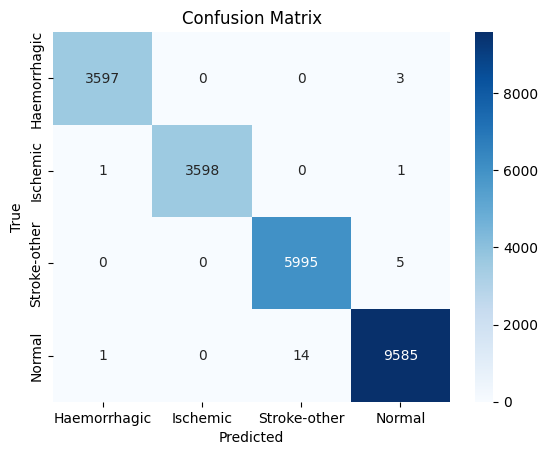

Epoch 1/30
  Train Loss: 0.0104, Train Acc: 0.9952
  Val Loss: 0.0015, Val Acc: 0.9989
  LR: 0.000010
  ✓ New best model saved! Val Acc: 0.9989
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


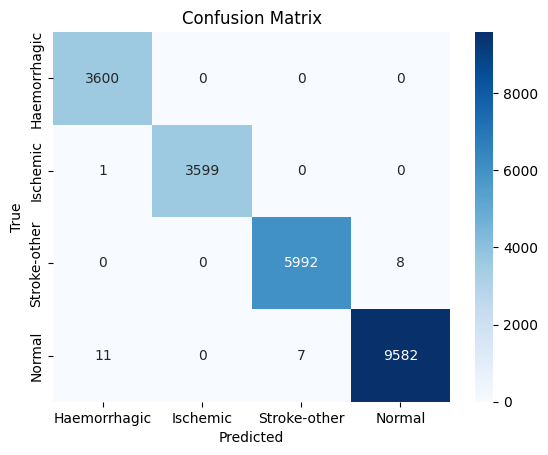

Epoch 2/30
  Train Loss: 0.0059, Train Acc: 0.9972
  Val Loss: 0.0011, Val Acc: 0.9988
  LR: 0.000010
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


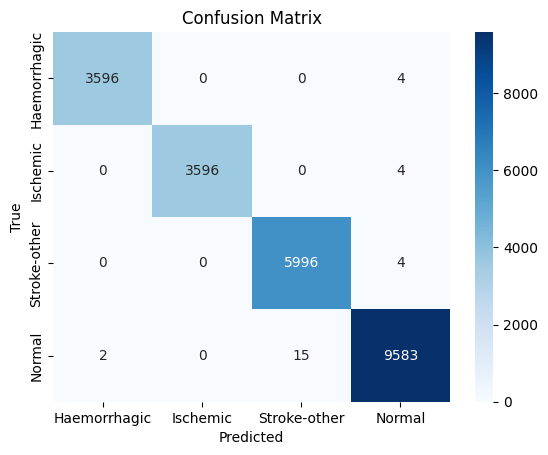

Epoch 3/30
  Train Loss: 0.0050, Train Acc: 0.9973
  Val Loss: 0.0010, Val Acc: 0.9987
  LR: 0.000010
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


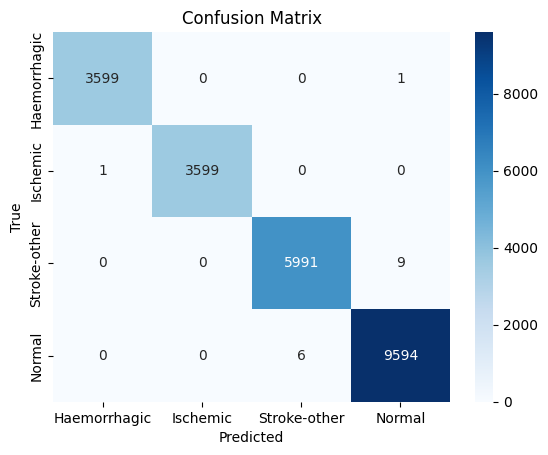

Epoch 4/30
  Train Loss: 0.0047, Train Acc: 0.9978
  Val Loss: 0.0007, Val Acc: 0.9993
  LR: 0.000010
  ✓ New best model saved! Val Acc: 0.9993
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


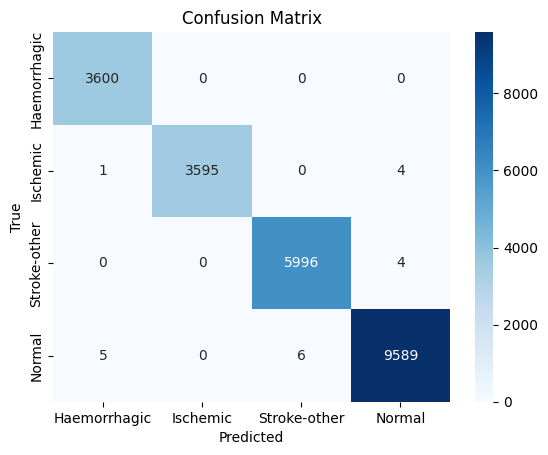

Epoch 5/30
  Train Loss: 0.0038, Train Acc: 0.9980
  Val Loss: 0.0009, Val Acc: 0.9991
  LR: 0.000009
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


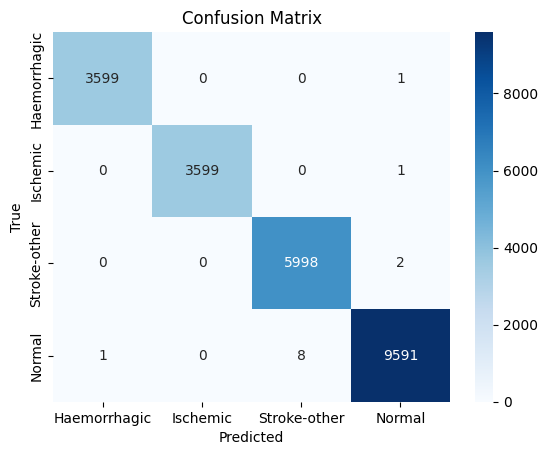

Epoch 6/30
  Train Loss: 0.0034, Train Acc: 0.9984
  Val Loss: 0.0006, Val Acc: 0.9994
  LR: 0.000009
  ✓ New best model saved! Val Acc: 0.9994
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


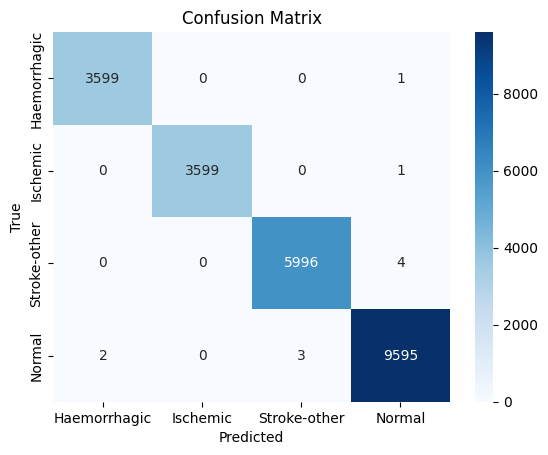

Epoch 7/30
  Train Loss: 0.0026, Train Acc: 0.9986
  Val Loss: 0.0005, Val Acc: 0.9995
  LR: 0.000009
  ✓ New best model saved! Val Acc: 0.9995
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


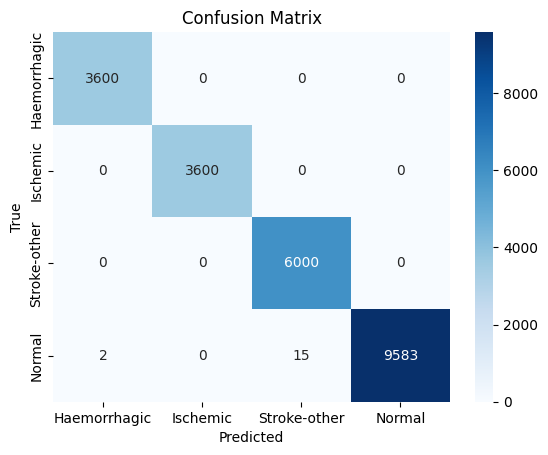

Epoch 8/30
  Train Loss: 0.0029, Train Acc: 0.9986
  Val Loss: 0.0007, Val Acc: 0.9993
  LR: 0.000008
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


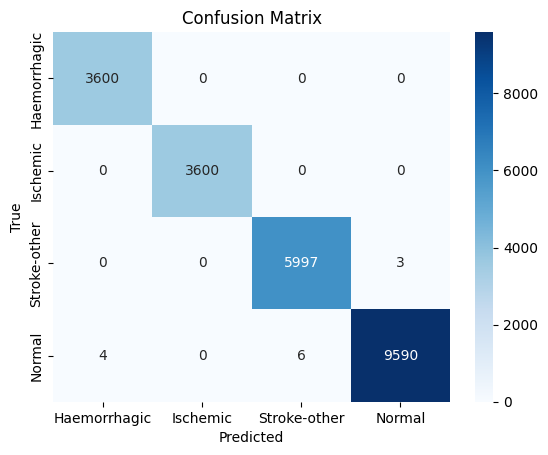

Epoch 9/30
  Train Loss: 0.0029, Train Acc: 0.9988
  Val Loss: 0.0006, Val Acc: 0.9994
  LR: 0.000008
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


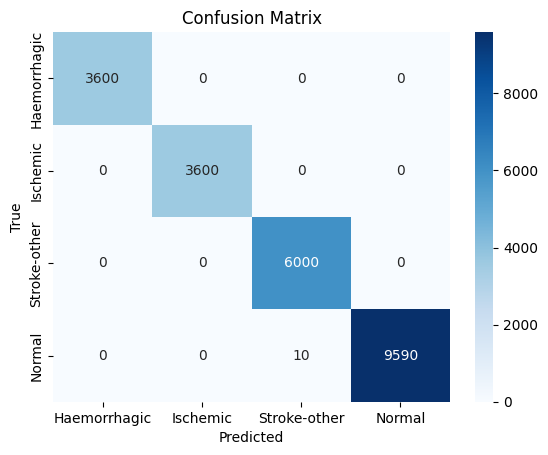

Epoch 10/30
  Train Loss: 0.0024, Train Acc: 0.9989
  Val Loss: 0.0003, Val Acc: 0.9996
  LR: 0.000007
  ✓ New best model saved! Val Acc: 0.9996
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


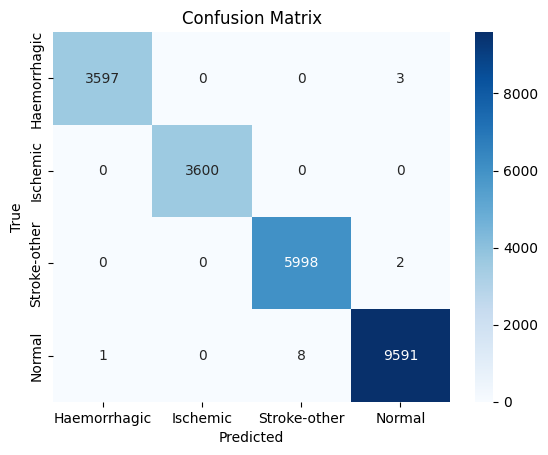

Epoch 11/30
  Train Loss: 0.0022, Train Acc: 0.9989
  Val Loss: 0.0006, Val Acc: 0.9994
  LR: 0.000007
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


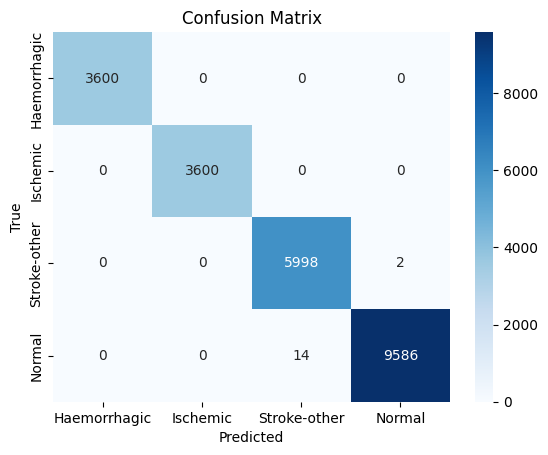

Epoch 12/30
  Train Loss: 0.0019, Train Acc: 0.9990
  Val Loss: 0.0005, Val Acc: 0.9993
  LR: 0.000007
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


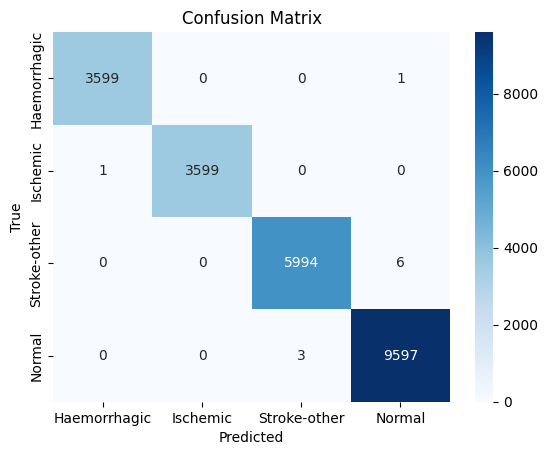

Epoch 13/30
  Train Loss: 0.0019, Train Acc: 0.9990
  Val Loss: 0.0005, Val Acc: 0.9995
  LR: 0.000006
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


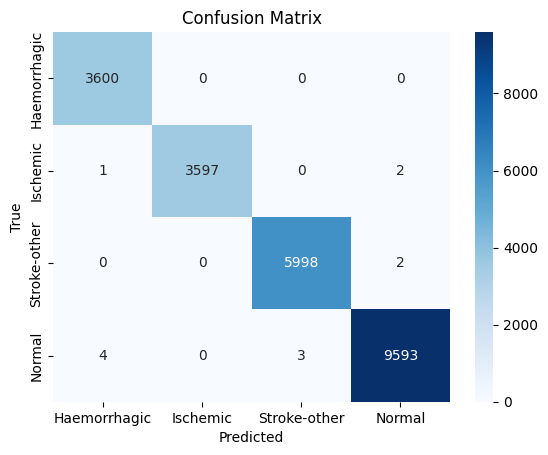

Epoch 14/30
  Train Loss: 0.0016, Train Acc: 0.9993
  Val Loss: 0.0005, Val Acc: 0.9995
  LR: 0.000006
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


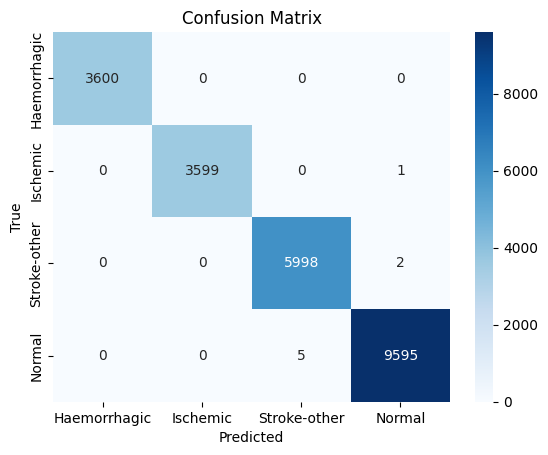

Epoch 15/30
  Train Loss: 0.0016, Train Acc: 0.9992
  Val Loss: 0.0003, Val Acc: 0.9996
  LR: 0.000005
  ✓ New best model saved! Val Acc: 0.9996
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


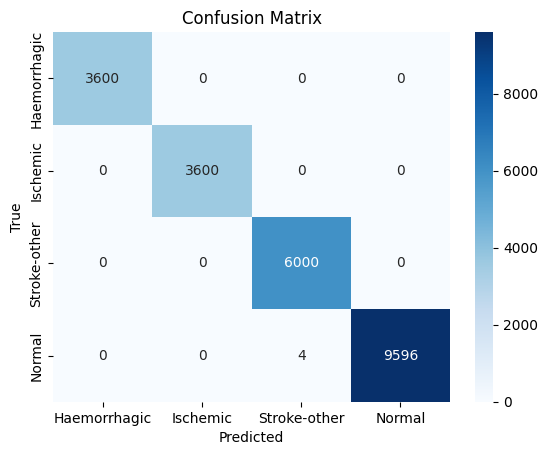

Epoch 16/30
  Train Loss: 0.0015, Train Acc: 0.9992
  Val Loss: 0.0002, Val Acc: 0.9998
  LR: 0.000004
  ✓ New best model saved! Val Acc: 0.9998
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


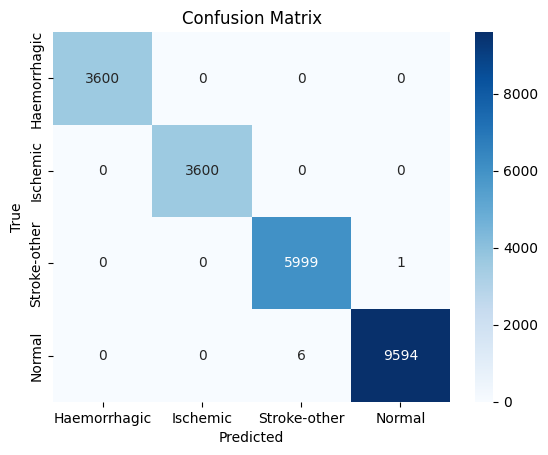

Epoch 17/30
  Train Loss: 0.0011, Train Acc: 0.9994
  Val Loss: 0.0002, Val Acc: 0.9997
  LR: 0.000004
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


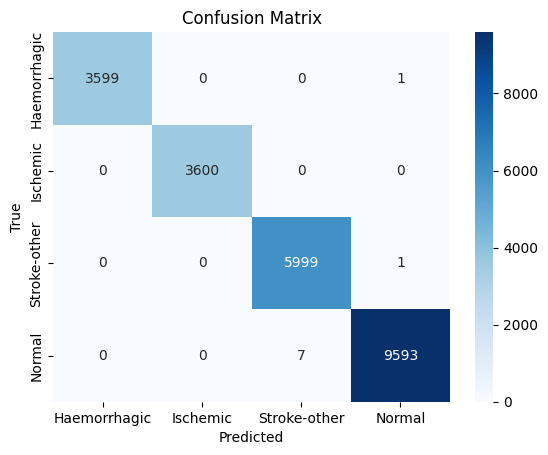

Epoch 18/30
  Train Loss: 0.0011, Train Acc: 0.9994
  Val Loss: 0.0002, Val Acc: 0.9996
  LR: 0.000003
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


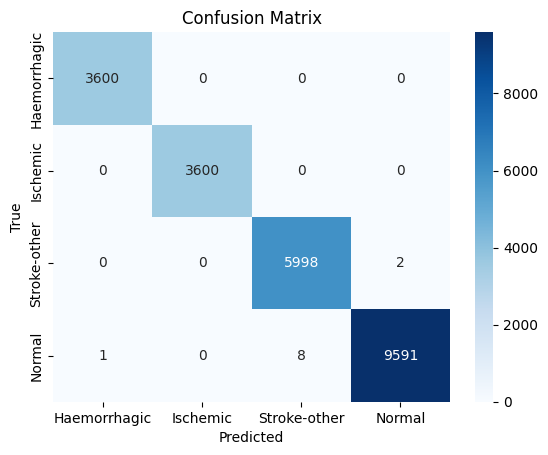

Epoch 19/30
  Train Loss: 0.0011, Train Acc: 0.9995
  Val Loss: 0.0003, Val Acc: 0.9995
  LR: 0.000003
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


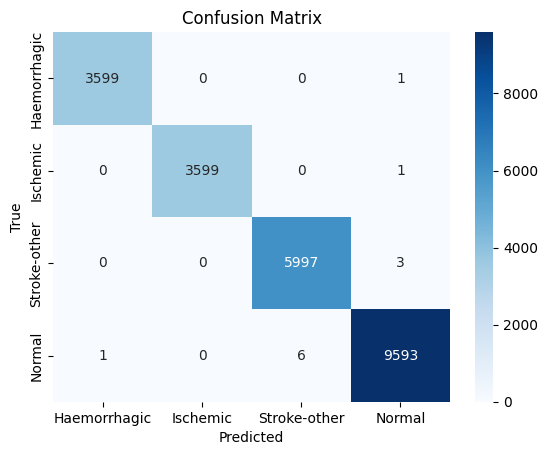

Epoch 20/30
  Train Loss: 0.0011, Train Acc: 0.9995
  Val Loss: 0.0005, Val Acc: 0.9995
  LR: 0.000003
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


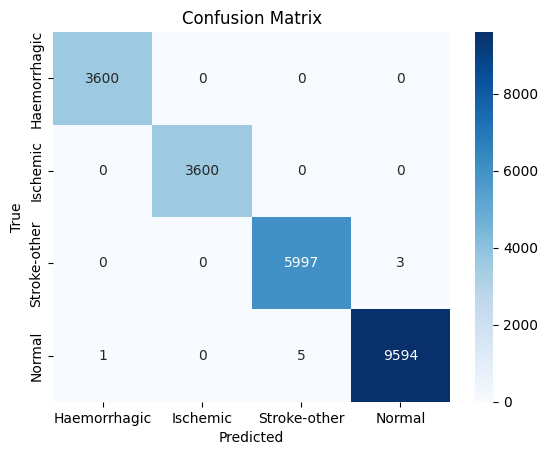

Epoch 21/30
  Train Loss: 0.0009, Train Acc: 0.9995
  Val Loss: 0.0002, Val Acc: 0.9996
  LR: 0.000002
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


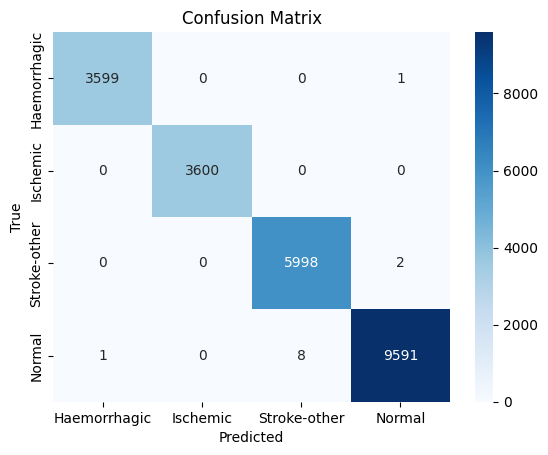

Epoch 22/30
  Train Loss: 0.0007, Train Acc: 0.9996
  Val Loss: 0.0003, Val Acc: 0.9995
  LR: 0.000002
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


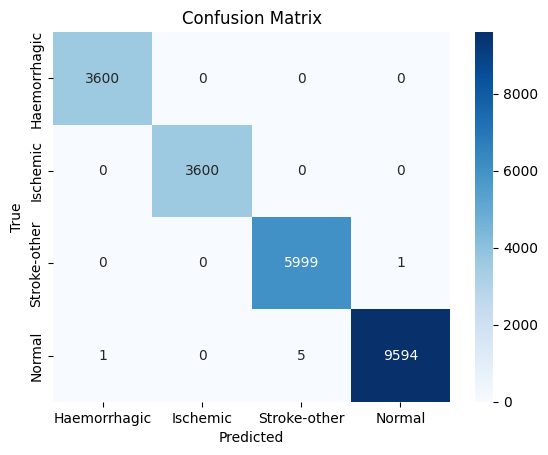

Epoch 23/30
  Train Loss: 0.0009, Train Acc: 0.9996
  Val Loss: 0.0002, Val Acc: 0.9997
  LR: 0.000001
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


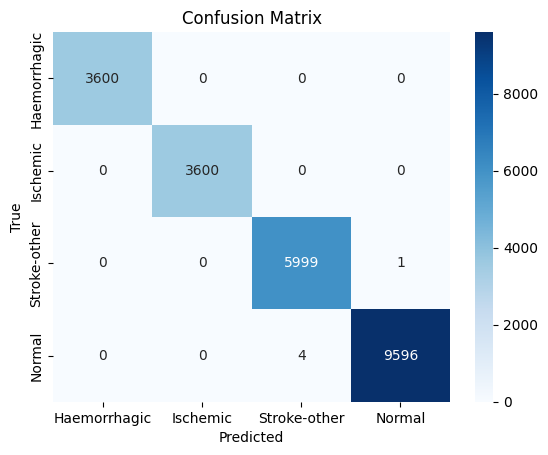

Epoch 24/30
  Train Loss: 0.0008, Train Acc: 0.9996
  Val Loss: 0.0002, Val Acc: 0.9998
  LR: 0.000001
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


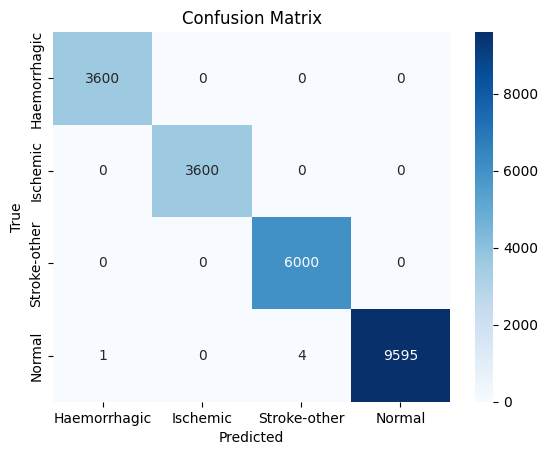

Epoch 25/30
  Train Loss: 0.0006, Train Acc: 0.9997
  Val Loss: 0.0001, Val Acc: 0.9998
  LR: 0.000001
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


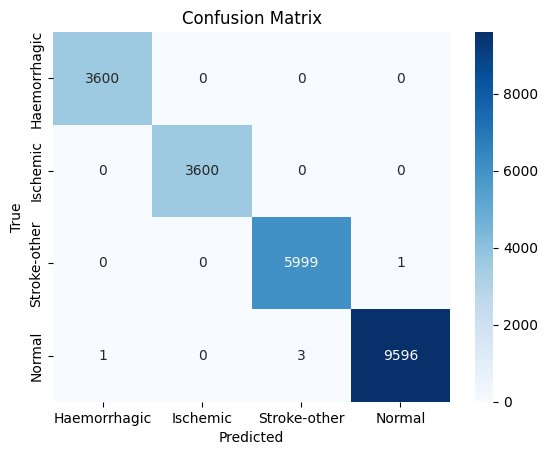

Epoch 26/30
  Train Loss: 0.0005, Train Acc: 0.9997
  Val Loss: 0.0002, Val Acc: 0.9998
  LR: 0.000000
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


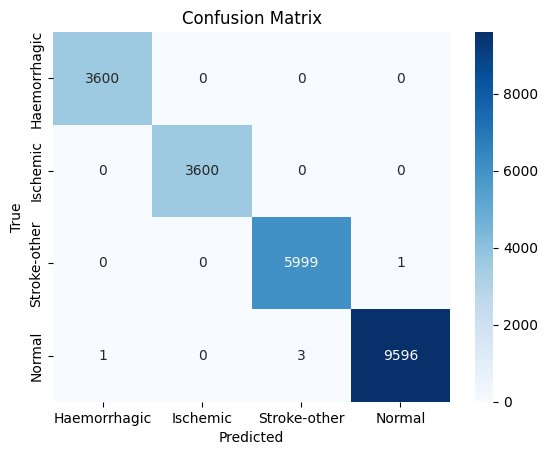

Epoch 27/30
  Train Loss: 0.0006, Train Acc: 0.9997
  Val Loss: 0.0001, Val Acc: 0.9998
  LR: 0.000000
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


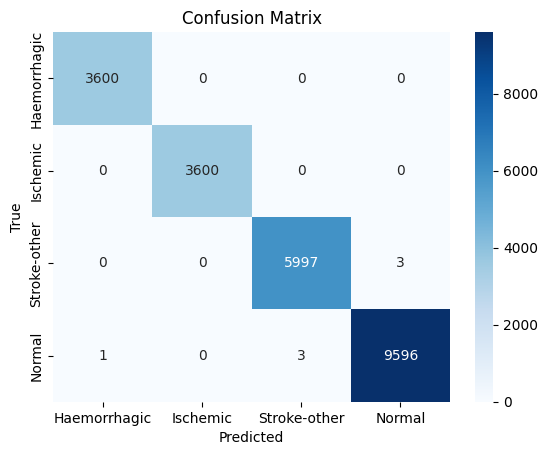

Epoch 28/30
  Train Loss: 0.0005, Train Acc: 0.9997
  Val Loss: 0.0001, Val Acc: 0.9997
  LR: 0.000000
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


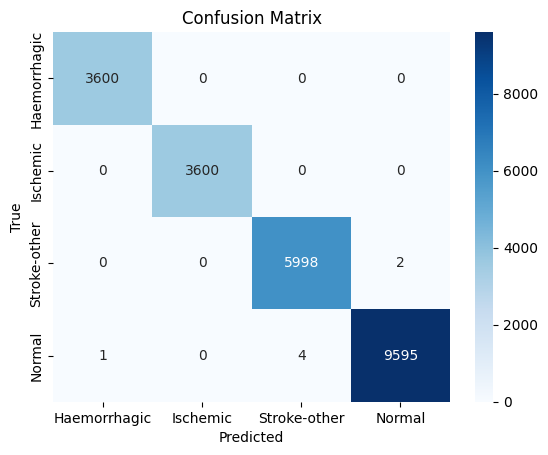

Epoch 29/30
  Train Loss: 0.0006, Train Acc: 0.9997
  Val Loss: 0.0001, Val Acc: 0.9997
  LR: 0.000000
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(3)]


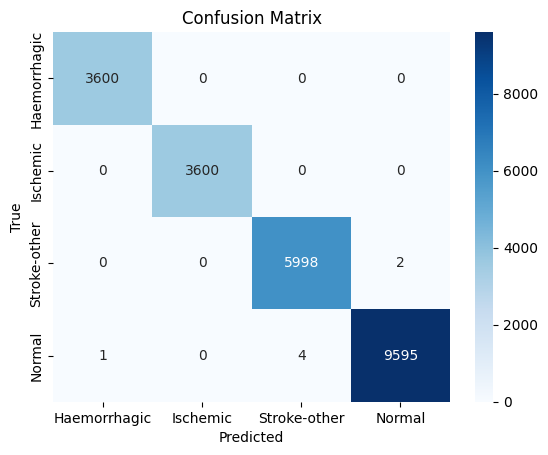

Epoch 30/30
  Train Loss: 0.0005, Train Acc: 0.9997
  Val Loss: 0.0001, Val Acc: 0.9997
  LR: 0.000000

ENHANCED MODEL EVALUATION
>> Sample val preds: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(2)]
>> Sample val labels: [np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(2)]


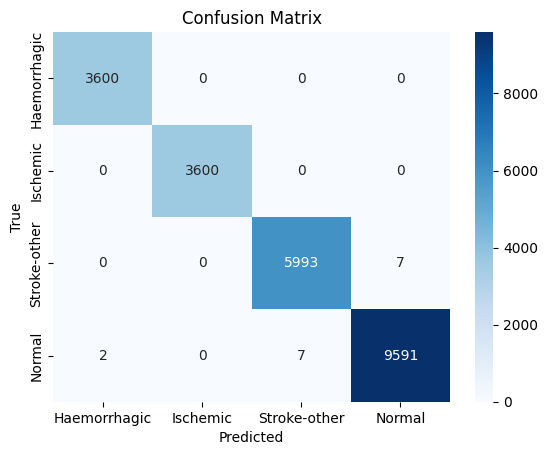

Enhanced Model Test Accuracy: 0.9993
Improvement over baseline: 0.2623

Classification Report:
              precision    recall  f1-score   support

Haemorrhagic       1.00      1.00      1.00      3600
    Ischemic       1.00      1.00      1.00      3600
Stroke-other       1.00      1.00      1.00      6000
      Normal       1.00      1.00      1.00      9600

    accuracy                           1.00     22800
   macro avg       1.00      1.00      1.00     22800
weighted avg       1.00      1.00      1.00     22800



In [14]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict
from sklearn.utils.multiclass import unique_labels
import math
from collections import Counter

# ------------------------
# 1. Your Original Dataset Classes (Unchanged)
# ------------------------
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

class UnpairedFusionDataset(Dataset):
    """
    Your original dataset class with optional mixup support
    """
    def __init__(self, ct_paths, ct_labels, mri_paths, mri_labels, transform, mixup_alpha=0.0):
        self.samples = []
        for p, l in zip(ct_paths, ct_labels):
            self.samples.append(('CT', p, l))
        for p, l in zip(mri_paths, mri_labels):
            self.samples.append(('MRI', p, l))
        self.transform = transform
        self.mixup_alpha = mixup_alpha

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        modality, path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label, modality

# ------------------------
# 2. Enhanced Fusion Model (Modified to use your pretrained weights)
# ------------------------
class EnhancedDualViTFusion(nn.Module):
    """
    Enhanced fusion model that can load your pretrained CT and MRI weights
    """
    def __init__(self, hidden_dim=768, num_classes=4, dropout_rate=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

        # Use same architecture as your original model for weight loading
        self.vit_ct = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224',
            num_labels=hidden_dim,
            ignore_mismatched_sizes=True
        )
        self.vit_mri = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224',
            num_labels=hidden_dim,
            ignore_mismatched_sizes=True
        )

        # Enhanced fusion components
        self.ct_projection = nn.Linear(hidden_dim, hidden_dim)
        self.mri_projection = nn.Linear(hidden_dim, hidden_dim)

        # Bidirectional cross-attention
        self.ct_to_mri_attn = nn.MultiheadAttention(hidden_dim, num_heads=8, dropout=dropout_rate)
        self.mri_to_ct_attn = nn.MultiheadAttention(hidden_dim, num_heads=8, dropout=dropout_rate)

        # Gated fusion mechanism
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

        # Feature enhancement
        self.feature_enhancer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )

        # Classification head (keeping your original simple version as option)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, num_classes)
        )

        # Store attention weights for visualization
        self.attention_weights = None

    def forward(self, ct=None, mri=None, return_attention=False):
        batch_size = ct.shape[0] if ct is not None else mri.shape[0]
        device = next(self.parameters()).device

        # Extract features (same as your original approach)
        if ct is not None:
            out_ct = self.vit_ct.vit(ct).last_hidden_state
            feat_ct = out_ct[:, 0]  # CLS token
            feat_ct = self.ct_projection(feat_ct)
        else:
            feat_ct = torch.zeros(batch_size, self.hidden_dim, device=device)

        if mri is not None:
            out_mri = self.vit_mri.vit(mri).last_hidden_state
            feat_mri = out_mri[:, 0]  # CLS token
            feat_mri = self.mri_projection(feat_mri)
        else:
            feat_mri = torch.zeros(batch_size, self.hidden_dim, device=device)

        # Enhanced bidirectional cross-attention
        ct_query = feat_ct.unsqueeze(0)
        mri_query = feat_mri.unsqueeze(0)

        # CT attending to MRI
        ct_attended, ct_attn_weights = self.ct_to_mri_attn(
            ct_query, mri_query, mri_query
        )
        ct_attended = ct_attended.squeeze(0)

        # MRI attending to CT
        mri_attended, mri_attn_weights = self.mri_to_ct_attn(
            mri_query, ct_query, ct_query
        )
        mri_attended = mri_attended.squeeze(0)

        # Store attention weights for visualization
        if return_attention:
            self.attention_weights = {
                'ct_to_mri': ct_attn_weights,
                'mri_to_ct': mri_attn_weights
            }

        # Residual connections
        ct_enhanced = feat_ct + ct_attended
        mri_enhanced = feat_mri + mri_attended

        # Feature enhancement
        ct_enhanced = self.feature_enhancer(ct_enhanced)
        mri_enhanced = self.feature_enhancer(mri_enhanced)

        # Gated fusion
        combined = torch.cat([ct_enhanced, mri_enhanced], dim=1)
        gate = self.fusion_gate(combined)
        fused_features = gate * ct_enhanced + (1 - gate) * mri_enhanced

        # Classification
        logits = self.classifier(fused_features)

        if return_attention:
            return logits, self.attention_weights

        return logits

# ------------------------
# 3. Enhanced Weight Loading (Modified to work with your weights)
# ------------------------
def load_pretrained_weights_enhanced(fusion_model, ct_weights_path, mri_weights_path):
    """
    Load your pretrained CT and MRI weights into the enhanced model
    """
    if os.path.exists(ct_weights_path):
        ct_state = torch.load(ct_weights_path, map_location='cpu')
        # Filter and adjust keys for vit_ct backbone
        ct_dict = {k.replace('vit.', ''): v for k, v in ct_state.items() if k.startswith('vit.')}
        fusion_model.vit_ct.vit.load_state_dict(ct_dict, strict=False)
        print("✓ CT pretrained weights loaded")
    else:
        print("⚠ CT weights not found, using random initialization")

    if os.path.exists(mri_weights_path):
        mri_state = torch.load(mri_weights_path, map_location='cpu')
        mri_dict = {k.replace('vit.', ''): v for k, v in mri_state.items() if k.startswith('vit.')}
        fusion_model.vit_mri.vit.load_state_dict(mri_dict, strict=False)
        print("✓ MRI pretrained weights loaded")
    else:
        print("⚠ MRI weights not found, using random initialization")

# ------------------------
# 4. Enhanced Loss Functions
# ------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ------------------------
# 5. Enhanced Evaluation (Modified from your original)
# ------------------------
# def evaluate_model_enhanced(model, loader, criterion, device, modality_type='mixed'):
#     """
#     Enhanced evaluation with attention visualization option
#     """
#     model.eval()
#     total_loss = 0.0
#     all_preds = []
#     all_labels = []
#     attention_maps = []

#     with torch.no_grad():
#         for batch_idx, batch in enumerate(loader):
#             if modality_type == 'mixed':
#                 imgs, labels, modalities = batch
#                 imgs = imgs.to(device)
#                 labels = labels.to(device)

#                 # Process CT samples
#                 ct_mask = [m == 'CT' for m in modalities]
#                 if any(ct_mask):
#                     ct_imgs = imgs[ct_mask]
#                     ct_lbls = labels[ct_mask]

#                     # Get attention maps for first batch
#                     if batch_idx == 0:
#                         logits_ct, attn_weights = model(ct=ct_imgs, mri=None, return_attention=True)
#                         attention_maps.append(('CT', attn_weights))
#                     else:
#                         logits_ct = model(ct=ct_imgs, mri=None)

#                     loss_ct = criterion(logits_ct, ct_lbls)
#                     total_loss += loss_ct.item()
#                     preds_ct = torch.argmax(logits_ct, dim=1)
#                     all_preds.extend(preds_ct.cpu().numpy())
#                     all_labels.extend(ct_lbls.cpu().numpy())

#                 # Process MRI samples
#                 mri_mask = [m == 'MRI' for m in modalities]
#                 if any(mri_mask):
#                     mri_imgs = imgs[mri_mask]
#                     mri_lbls = labels[mri_mask]

#                     # Get attention maps for first batch
#                     if batch_idx == 0:
#                         logits_mri, attn_weights = model(ct=None, mri=mri_imgs, return_attention=True)
#                         attention_maps.append(('MRI', attn_weights))
#                     else:
#                         logits_mri = model(ct=None, mri=mri_imgs)

#                     loss_mri = criterion(logits_mri, mri_lbls)
#                     total_loss += loss_mri.item()
#                     preds_mri = torch.argmax(logits_mri, dim=1)
#                     all_preds.extend(preds_mri.cpu().numpy())
#                     all_labels.extend(mri_lbls.cpu().numpy())
#             else:
#                 # Single modality evaluation
#                 imgs, labels = batch
#                 imgs = imgs.to(device)
#                 labels = labels.to(device)

#                 if modality_type == 'CT':
#                     logits = model(ct=imgs, mri=None)
#                 elif modality_type == 'MRI':
#                     logits = model(ct=None, mri=imgs)

#                 loss = criterion(logits, labels)
#                 total_loss += loss.item()
#                 preds = torch.argmax(logits, dim=1)
#                 all_preds.extend(preds.cpu().numpy())
#                 all_labels.extend(labels.cpu().numpy())

#     avg_loss = total_loss / len(loader)
#     accuracy = accuracy_score(all_labels, all_preds)
#     if len(all_preds) > 0:
#       print(">> Sample val preds:", all_preds[:10])
#       print(">> Sample val labels:", all_labels[:10])

#     # After test_preds, test_labels
#     cm = confusion_matrix(test_labels, test_preds)
#     sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
#     plt.title("Confusion Matrix")
#     plt.xlabel("Predicted")
#     plt.ylabel("True")
#     plt.show()


#     return avg_loss, accuracy, all_preds, all_labels, attention_maps

def evaluate_model_enhanced(model, loader, criterion, device, modality_type='mixed'):
    """
    Enhanced evaluation with attention visualization option
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    attention_maps = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if modality_type == 'mixed':
                imgs, labels, modalities = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                # Process CT samples
                ct_mask = [m == 'CT' for m in modalities]
                if any(ct_mask):
                    ct_imgs = imgs[ct_mask]
                    ct_lbls = labels[ct_mask]

                    # Get attention maps for first batch
                    if batch_idx == 0:
                        logits_ct, attn_weights = model(ct=ct_imgs, mri=None, return_attention=True)
                        attention_maps.append(('CT', attn_weights))
                    else:
                        logits_ct = model(ct=ct_imgs, mri=None)

                    loss_ct = criterion(logits_ct, ct_lbls)
                    total_loss += loss_ct.item()
                    preds_ct = torch.argmax(logits_ct, dim=1)
                    all_preds.extend(preds_ct.cpu().numpy())
                    all_labels.extend(ct_lbls.cpu().numpy())

                # Process MRI samples
                mri_mask = [m == 'MRI' for m in modalities]
                if any(mri_mask):
                    mri_imgs = imgs[mri_mask]
                    mri_lbls = labels[mri_mask]

                    # Get attention maps for first batch
                    if batch_idx == 0:
                        logits_mri, attn_weights = model(ct=None, mri=mri_imgs, return_attention=True)
                        attention_maps.append(('MRI', attn_weights))
                    else:
                        logits_mri = model(ct=None, mri=mri_imgs)

                    loss_mri = criterion(logits_mri, mri_lbls)
                    total_loss += loss_mri.item()
                    preds_mri = torch.argmax(logits_mri, dim=1)
                    all_preds.extend(preds_mri.cpu().numpy())
                    all_labels.extend(mri_lbls.cpu().numpy())
            else:
                # Single modality evaluation
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                if modality_type == 'CT':
                    logits = model(ct=imgs, mri=None)
                elif modality_type == 'MRI':
                    logits = model(ct=None, mri=imgs)

                loss = criterion(logits, labels)
                total_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    # Print a few predictions for sanity check
    print(">> Sample val preds:", all_preds[:10])
    print(">> Sample val labels:", all_labels[:10])

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return avg_loss, accuracy, all_preds, all_labels, attention_maps

# ------------------------
# 6. Enhanced Training Loop (Using your config)
# ------------------------
def train_enhanced_model():
    # Your original configuration
    CT_DIR = '/content/Balanced_dataset'
    MRI_DIR = '/content/Balanced_MRI_Dataset'
    CT_WEIGHTS = '/content/Balanced_dataset_vit_stroke.pth'
    MRI_WEIGHTS = '/content/Aug_dataset_vit_stroke_mri.pth'
    BATCH_SIZE = 64  # Reduced for better training
    NUM_EPOCHS = 30
    LR = 1e-4
    NUM_CLASSES = 4
    CLASS_NAMES = ['Haemorrhagic', 'Ischemic', 'Stroke-other', 'Normal']

    # Enhanced transforms
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.485]*3, [0.229]*3)
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485]*3, [0.229]*3)
    ])

    # Load data (your original code)
    def load_paths(root, classes):
        paths, labels = [], []
        for idx, cls in enumerate(classes):
            p_dir = os.path.join(root, cls)
            if not os.path.isdir(p_dir):
                print(f"Warning: Directory {p_dir} not found or inaccessible.")
                continue
            try:
                for fname in os.listdir(p_dir):
                    if fname.lower().endswith(('png','jpg','jpeg','bmp','tiff')):
                        paths.append(os.path.join(p_dir, fname))
                        labels.append(idx)
            except OSError as e:
                print(f"Warning: Cannot access directory {p_dir}: {e}")
                continue
        return paths, labels

    ct_paths, ct_labels = load_paths(CT_DIR, ['Stroke', 'Normal'])
    mri_paths, mri_labels = load_paths(MRI_DIR, ['Haemorrhagic', 'Ischemic', 'Normal'])

    # Label remapping (your original code)
    ct_label_remap = {0: 2, 1: 3}
    ct_labels = [ct_label_remap[lbl] for lbl in ct_labels]

    mri_label_remap = {0: 0, 1: 1, 2: 3}
    mri_labels = [mri_label_remap[lbl] for lbl in mri_labels]

    print("CT label distribution:", Counter(ct_labels))
    print("MRI label distribution:", Counter(mri_labels))


    # Data splits (your original code)
    ct_train, ct_temp, lbl_ct_train, lbl_ct_temp = train_test_split(
        ct_paths, ct_labels, test_size=0.2, stratify=ct_labels, random_state=42)
    ct_val, ct_test, lbl_ct_val, lbl_ct_test = train_test_split(
        ct_temp, lbl_ct_temp, test_size=0.5, stratify=lbl_ct_temp, random_state=42)

    mri_train, mri_temp, lbl_mri_train, lbl_mri_temp = train_test_split(
        mri_paths, mri_labels, test_size=0.2, stratify=mri_labels, random_state=42)
    mri_val, mri_test, lbl_mri_val, lbl_mri_test = train_test_split(
        mri_temp, lbl_mri_temp, test_size=0.5, stratify=lbl_mri_temp, random_state=42)

    print(f"CT Data - Train: {len(ct_train)}, Val: {len(ct_val)}, Test: {len(ct_test)}")
    print(f"MRI Data - Train: {len(mri_train)}, Val: {len(mri_val)}, Test: {len(mri_test)}")

    def check_overlap(sets, name):
        all_paths = sum(sets, [])
        unique_paths = set(all_paths)
        if len(all_paths) != len(unique_paths):
            print(f"⚠ Overlap detected in {name} splits!")
        else:
            print(f"✓ No overlap in {name} splits.")

    check_overlap([ct_train, ct_val, ct_test], "CT")
    check_overlap([mri_train, mri_val, mri_test], "MRI")


    # Create datasets
    train_ds = UnpairedFusionDataset(ct_train, lbl_ct_train, mri_train, lbl_mri_train, train_transform)
    val_ds = UnpairedFusionDataset(ct_val, lbl_ct_val, mri_val, lbl_mri_val, val_test_transform)
    test_ds = UnpairedFusionDataset(ct_test, lbl_ct_test, mri_test, lbl_mri_test, val_test_transform)

    # Create data loaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    # Initialize enhanced model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model = EnhancedDualViTFusion(hidden_dim=768, num_classes=NUM_CLASSES, dropout_rate=0.1).to(device)

    # Load your pretrained weights
    load_pretrained_weights_enhanced(model, CT_WEIGHTS, MRI_WEIGHTS)

    # Enhanced training setup
    criterion = FocalLoss(alpha=1.0, gamma=2.0)  # Better for class imbalance

    # Differential learning rates
    backbone_params = []
    fusion_params = []

    for name, param in model.named_parameters():
        if 'vit_ct' in name or 'vit_mri' in name:
            backbone_params.append(param)
        else:
            fusion_params.append(param)

    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': LR * 0.1},  # Lower LR for pretrained parts
        {'params': fusion_params, 'lr': LR}           # Higher LR for new components
    ], weight_decay=1e-4)

    # Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # Training loop
    print("Starting Enhanced Training...")
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(1, NUM_EPOCHS + 1):
        # Training phase
        model.train()
        total_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for imgs, labels, modalities in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            loss = 0.0

            # CT samples
            ct_mask = [m == 'CT' for m in modalities]
            if any(ct_mask):
                ct_imgs = imgs[ct_mask]
                ct_lbls = labels[ct_mask]
                logits_ct = model(ct=ct_imgs, mri=None)
                loss_ct = criterion(logits_ct, ct_lbls)
                loss += loss_ct
                preds_ct = torch.argmax(logits_ct, dim=1)
                all_train_preds.extend(preds_ct.cpu().numpy())
                all_train_labels.extend(ct_lbls.cpu().numpy())

            # MRI samples
            mri_mask = [m == 'MRI' for m in modalities]
            if any(mri_mask):
                mri_imgs = imgs[mri_mask]
                mri_lbls = labels[mri_mask]
                logits_mri = model(ct=None, mri=mri_imgs)
                loss_mri = criterion(logits_mri, mri_lbls)
                loss += loss_mri
                preds_mri = torch.argmax(logits_mri, dim=1)
                all_train_preds.extend(preds_mri.cpu().numpy())
                all_train_labels.extend(mri_lbls.cpu().numpy())

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        # Calculate training metrics
        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_train_labels, all_train_preds)

        # Validation phase
        val_loss, val_acc, val_preds, val_labels, attention_maps = evaluate_model_enhanced(
            model, val_loader, criterion, device, 'mixed')

        # Update learning rate
        scheduler.step()

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print progress
        print(f"Epoch {epoch}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_enhanced_fusion_model.pth')
            print(f"  ✓ New best model saved! Val Acc: {val_acc:.4f}")

    # Final evaluation
    print("\n" + "="*50)
    print("ENHANCED MODEL EVALUATION")
    print("="*50)

    model.load_state_dict(torch.load('best_enhanced_fusion_model.pth'))
    test_loss, test_acc, test_preds, test_labels, test_attention = evaluate_model_enhanced(
        model, test_loader, criterion, device, 'mixed')

    print(f"Enhanced Model Test Accuracy: {test_acc:.4f}")
    print(f"Improvement over baseline: {test_acc - 0.737:.4f}")

    # Classification report
    present_labels = sorted(list(unique_labels(test_labels, test_preds)))
    present_class_names = [CLASS_NAMES[i] for i in present_labels]
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=present_class_names, labels=present_labels))

    return model, train_losses, val_losses, train_accs, val_accs

# Run the enhanced training
if __name__ == '__main__':
    model, train_losses, val_losses, train_accs, val_accs = train_enhanced_model()